# 🏠 Model Evaluation - Rent & Sale Price Prediction
### Cross-Validation + Performance Graphs + Model Info

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Load data ──────────────────────────────────────────────────────────────
df_rent = pd.read_csv('dataset for rent 1.csv')
df_sale = pd.read_csv('dataset for sale 1.csv')

df_rent = df_rent.drop(columns=['size_m2', 'listing_type']).rename(columns={'price': 'price_per_m2'})
df_sale = df_sale.drop(columns=['size_m2', 'listing_type']).rename(columns={'price': 'price_per_m2'})

feature_columns = [
    'latitude', 'longitude', 'location_name', 'bedrooms', 'bathrooms',
    'property_type', 'condition',
    'near_school', 'near_hospital', 'near_market', 'parking', 'security_rating'
]

X_rent = df_rent[feature_columns]
y_rent = df_rent['price_per_m2']
X_sale = df_sale[feature_columns]
y_sale = df_sale['price_per_m2']

# ── Load trained models ────────────────────────────────────────────────────
rent_model = joblib.load('rent_model_no_distance.pkl')
sale_model = joblib.load('sale_model_no_distance.pkl')

print('✅ Data and models loaded successfully')
print(f'   Rent dataset : {X_rent.shape[0]} rows, {X_rent.shape[1]} features')
print(f'   Sale dataset : {X_sale.shape[0]} rows, {X_sale.shape[1]} features')

✅ Data and models loaded successfully
   Rent dataset : 1000 rows, 12 features
   Sale dataset : 1000 rows, 12 features


## 1️⃣  Model Identity — What is inside each .pkl file?

In [2]:
def print_model_info(name, pipeline):
    regressor = pipeline.named_steps['regressor']
    print('=' * 55)
    print(f'  MODEL : {name}')
    print('=' * 55)
    print(f'  Algorithm      : {type(regressor).__name__}')
    print(f'  n_estimators   : {regressor.n_estimators}')
    print(f'  max_depth      : {regressor.max_depth}')
    print(f'  min_samples_leaf: {regressor.min_samples_leaf}')
    print(f'  random_state   : {regressor.random_state}')
    print(f'  n_features_in_ : {regressor.n_features_in_}')
    print()

print_model_info('Rent Price Model  (rent_model_no_distance.pkl)', rent_model)
print_model_info('Sale Price Model  (sale_model_no_distance.pkl)', sale_model)

  MODEL : Rent Price Model  (rent_model_no_distance.pkl)
  Algorithm      : RandomForestRegressor
  n_estimators   : 100
  max_depth      : None
  min_samples_leaf: 1
  random_state   : 42
  n_features_in_ : 27

  MODEL : Sale Price Model  (sale_model_no_distance.pkl)
  Algorithm      : RandomForestRegressor
  n_estimators   : 100
  max_depth      : None
  min_samples_leaf: 1
  random_state   : 42
  n_features_in_ : 27



## 2️⃣  Cross-Validation — 5-Fold (checks for overfitting)

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for label, model, X, y in [
    ('RENT', rent_model, X_rent, y_rent),
    ('SALE', sale_model, X_sale, y_sale)
]:
    cv_r2   = cross_val_score(model, X, y, cv=kf, scoring='r2')
    cv_mae  = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error'))

    # Train score (to detect overfitting: train >> cv means overfit)
    model.fit(X, y)
    train_r2 = model.score(X, y)

    results[label] = {
        'cv_r2': cv_r2, 'cv_mae': cv_mae, 'cv_rmse': cv_rmse,
        'train_r2': train_r2
    }

    unit = 'ETB/m²'
    print(f'\n{'─'*55}')
    print(f'  {label} MODEL — 5-Fold Cross-Validation')
    print(f'{'─'*55}')
    print(f'  Train  R²  (full data) : {train_r2:.4f}   ← should be close to CV')
    print(f'  CV     R²  (mean ± std): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
    print(f'  CV     MAE (mean ± std): {cv_mae.mean():.2f} ± {cv_mae.std():.2f} {unit}')
    print(f'  CV     RMSE(mean ± std): {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} {unit}')
    print(f'  Per-fold R²: {np.round(cv_r2, 4)}')

    gap = train_r2 - cv_r2.mean()
    if gap > 0.05:
        print(f'  ⚠️  Overfit gap = {gap:.4f}  (train R² much higher than CV R²)')
    else:
        print(f'  ✅  No significant overfitting  (gap = {gap:.4f})')


───────────────────────────────────────────────────────
  RENT MODEL — 5-Fold Cross-Validation
───────────────────────────────────────────────────────
  Train  R²  (full data) : 0.9987   ← should be close to CV
  CV     R²  (mean ± std): 0.9875 ± 0.0038
  CV     MAE (mean ± std): 17.63 ± 3.85 ETB/m²
  CV     RMSE(mean ± std): 25.87 ± 4.85 ETB/m²
  Per-fold R²: [0.9859 0.9838 0.9858 0.9875 0.9947]
  ✅  No significant overfitting  (gap = 0.0111)

───────────────────────────────────────────────────────
  SALE MODEL — 5-Fold Cross-Validation
───────────────────────────────────────────────────────
  Train  R²  (full data) : 0.9999   ← should be close to CV
  CV     R²  (mean ± std): 0.9993 ± 0.0002
  CV     MAE (mean ± std): 329.79 ± 57.67 ETB/m²
  CV     RMSE(mean ± std): 599.77 ± 95.19 ETB/m²
  Per-fold R²: [0.9991 0.9992 0.9992 0.9996 0.9996]
  ✅  No significant overfitting  (gap = 0.0006)


## 3️⃣  Performance Graphs

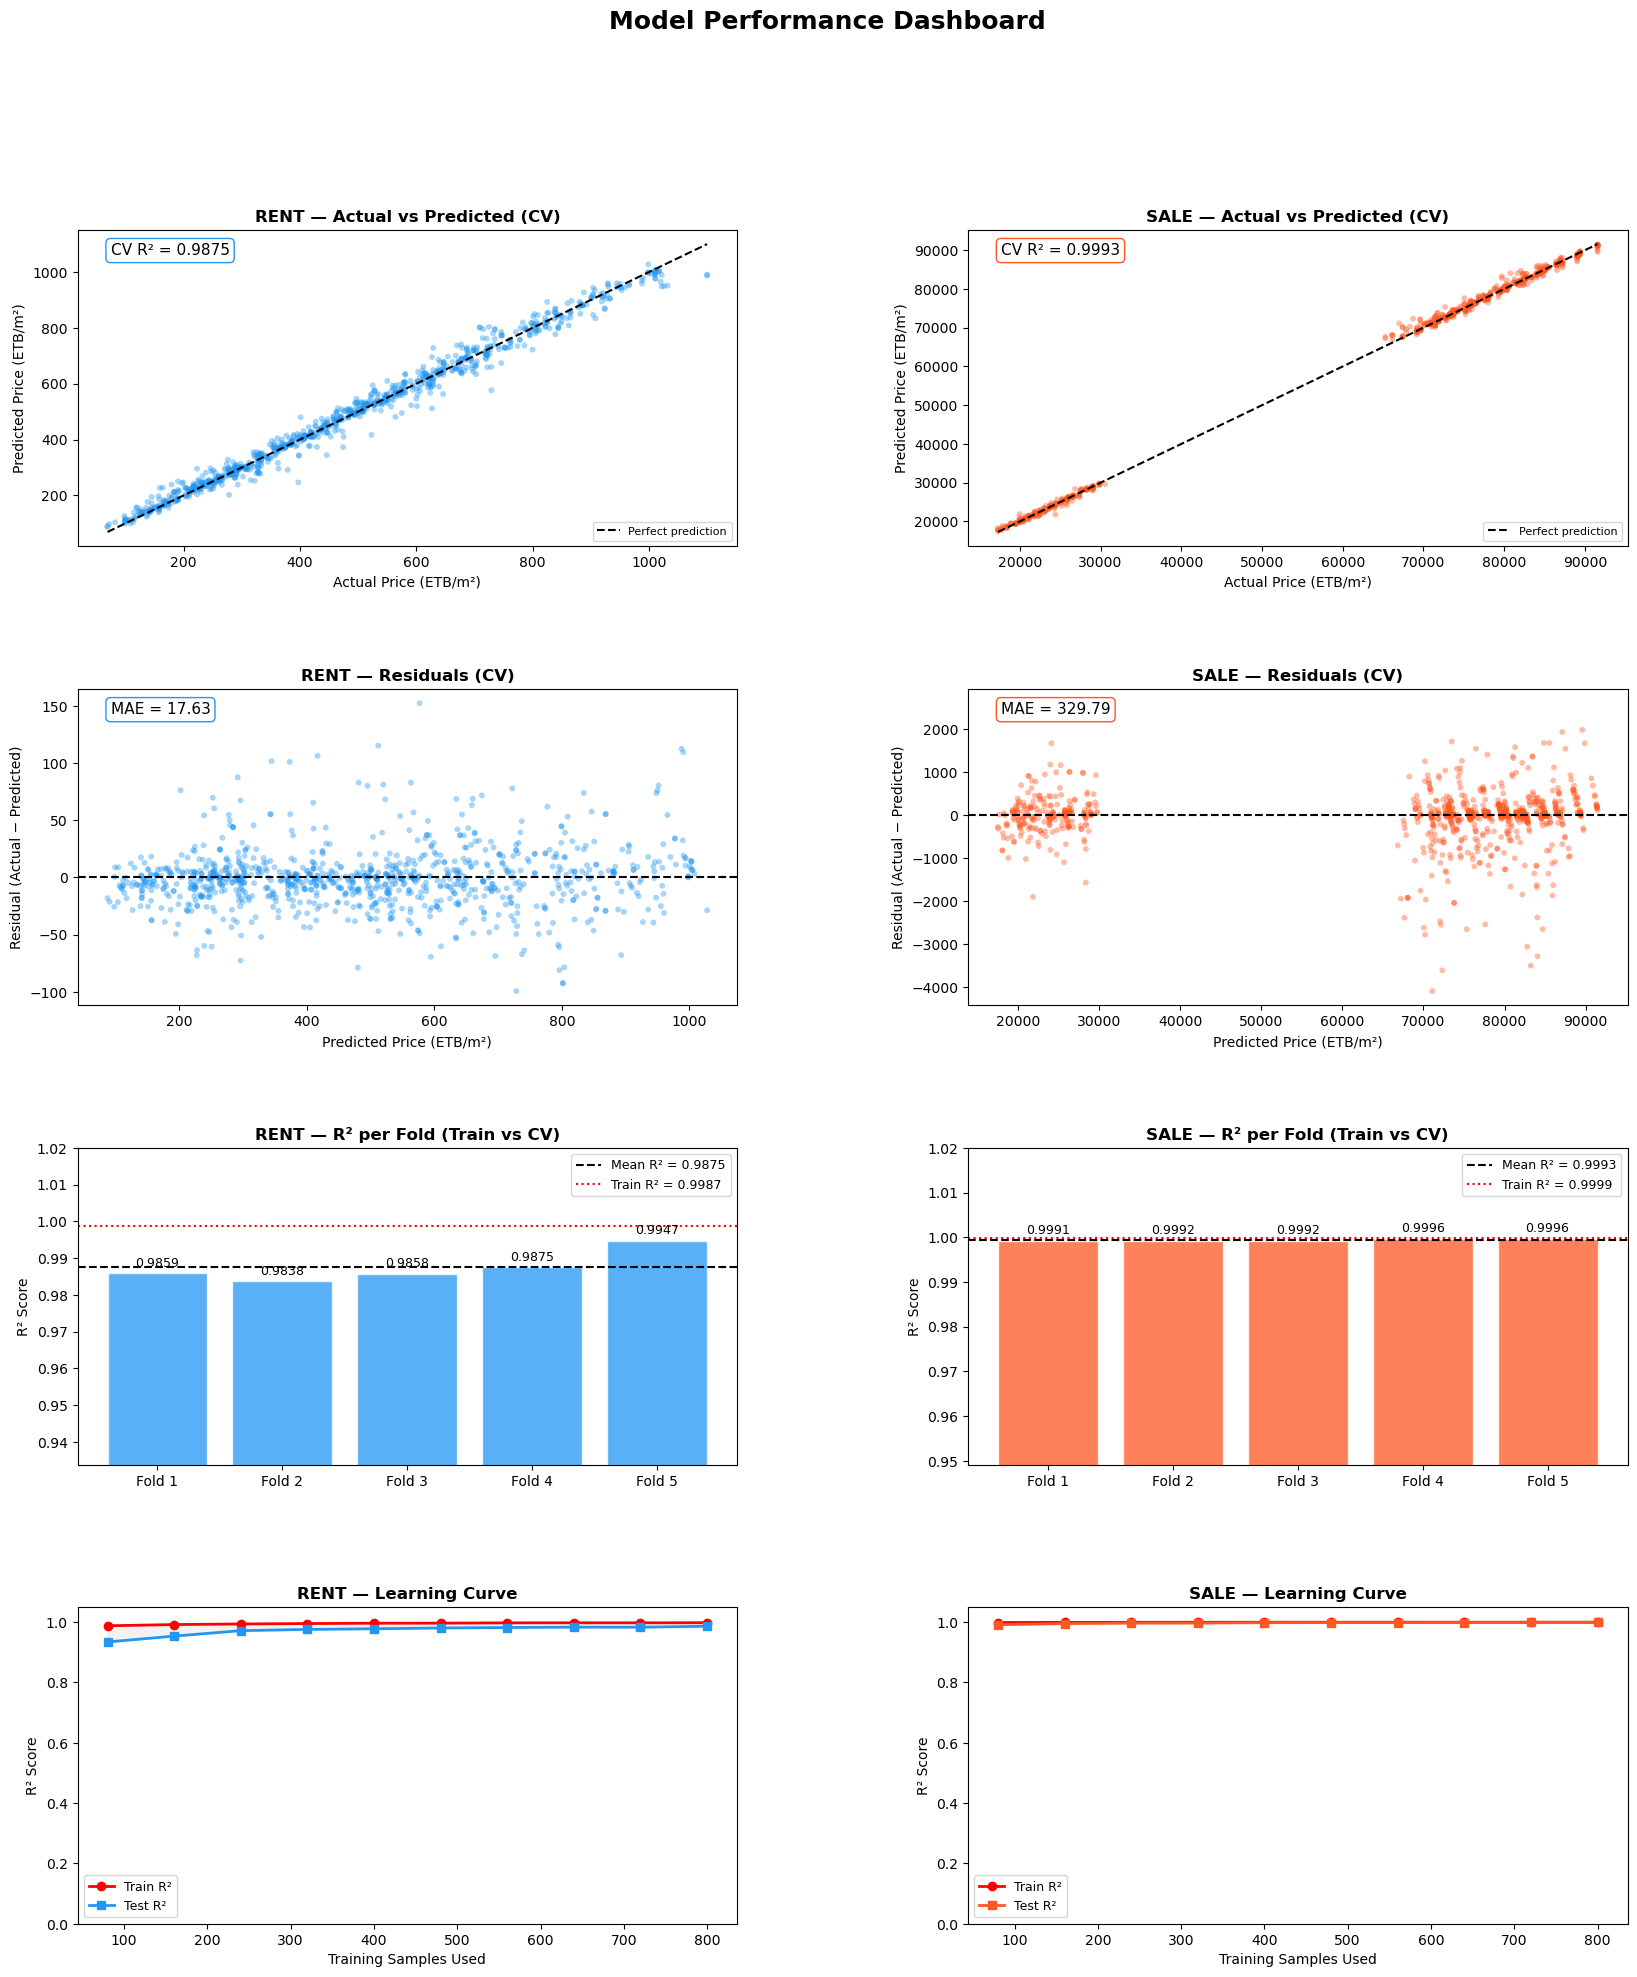


📊 Graph saved as model_performance.png


In [4]:
from sklearn.model_selection import train_test_split

fig = plt.figure(figsize=(20, 22))
fig.suptitle('Model Performance Dashboard', fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {'RENT': '#2196F3', 'SALE': '#FF5722'}

for col_idx, (label, model, X, y) in enumerate([
    ('RENT', rent_model, X_rent, y_rent),
    ('SALE', sale_model, X_sale, y_sale)
]):
    color = COLORS[label]
    cv_data = results[label]

    # ── Cross-val predictions for scatter / residuals ──────────────────────
    y_cv_pred = cross_val_predict(model, X, y, cv=kf)

    # ── Train/test split for learning curve proxy ──────────────────────────
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_tr, y_tr)
    y_test_pred = model.predict(X_te)

    # ── GRAPH 1: Actual vs Predicted ───────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, col_idx])
    ax1.scatter(y, y_cv_pred, alpha=0.4, s=18, color=color, edgecolors='none')
    mn, mx = y.min(), y.max()
    ax1.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect prediction')
    ax1.set_title(f'{label} — Actual vs Predicted (CV)', fontweight='bold')
    ax1.set_xlabel('Actual Price (ETB/m²)')
    ax1.set_ylabel('Predicted Price (ETB/m²)')
    r2_cv = r2_score(y, y_cv_pred)
    ax1.text(0.05, 0.92, f'CV R² = {r2_cv:.4f}', transform=ax1.transAxes,
             fontsize=11, color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color))
    ax1.legend(fontsize=8)

    # ── GRAPH 2: Residuals ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, col_idx])
    residuals = y - y_cv_pred
    ax2.scatter(y_cv_pred, residuals, alpha=0.4, s=18, color=color, edgecolors='none')
    ax2.axhline(0, color='black', lw=1.5, linestyle='--')
    ax2.set_title(f'{label} — Residuals (CV)', fontweight='bold')
    ax2.set_xlabel('Predicted Price (ETB/m²)')
    ax2.set_ylabel('Residual (Actual − Predicted)')
    ax2.text(0.05, 0.92, f'MAE = {mean_absolute_error(y, y_cv_pred):.2f}',
             transform=ax2.transAxes, fontsize=11,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color))

    # ── GRAPH 3: CV R² per fold (bar chart) ───────────────────────────────
    ax3 = fig.add_subplot(gs[2, col_idx])
    folds = [f'Fold {i+1}' for i in range(5)]
    bars = ax3.bar(folds, cv_data['cv_r2'], color=color, alpha=0.75, edgecolor='white')
    ax3.axhline(cv_data['cv_r2'].mean(), color='black', lw=1.5,
                linestyle='--', label=f"Mean R² = {cv_data['cv_r2'].mean():.4f}")
    ax3.axhline(cv_data['train_r2'], color='red', lw=1.5,
                linestyle=':', label=f"Train R² = {cv_data['train_r2']:.4f}")
    for bar, val in zip(bars, cv_data['cv_r2']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax3.set_ylim(max(0, cv_data['cv_r2'].min() - 0.05), 1.02)
    ax3.set_title(f'{label} — R² per Fold (Train vs CV)', fontweight='bold')
    ax3.set_ylabel('R² Score')
    ax3.legend(fontsize=9)

    # ── GRAPH 4: Learning Curve (train size vs score) ──────────────────────
    ax4 = fig.add_subplot(gs[3, col_idx])
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_r2s, test_r2s = [], []
    for frac in train_sizes:
        n = max(10, int(frac * len(X_tr)))
        X_sub, y_sub = X_tr.iloc[:n], y_tr.iloc[:n]
        model.fit(X_sub, y_sub)
        train_r2s.append(model.score(X_sub, y_sub))
        test_r2s.append(model.score(X_te, y_te))
    sizes_abs = (train_sizes * len(X_tr)).astype(int)
    ax4.plot(sizes_abs, train_r2s, 'o-', color='red',   label='Train R²',      lw=2)
    ax4.plot(sizes_abs, test_r2s,  's-', color=color,   label='Test R²',       lw=2)
    ax4.fill_between(sizes_abs, train_r2s, test_r2s, alpha=0.1, color='gray')
    ax4.set_title(f'{label} — Learning Curve', fontweight='bold')
    ax4.set_xlabel('Training Samples Used')
    ax4.set_ylabel('R² Score')
    ax4.legend(fontsize=9)
    ax4.set_ylim(0, 1.05)

plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Graph saved as model_performance.png')

## 4️⃣  Feature Importance — What drives the price?

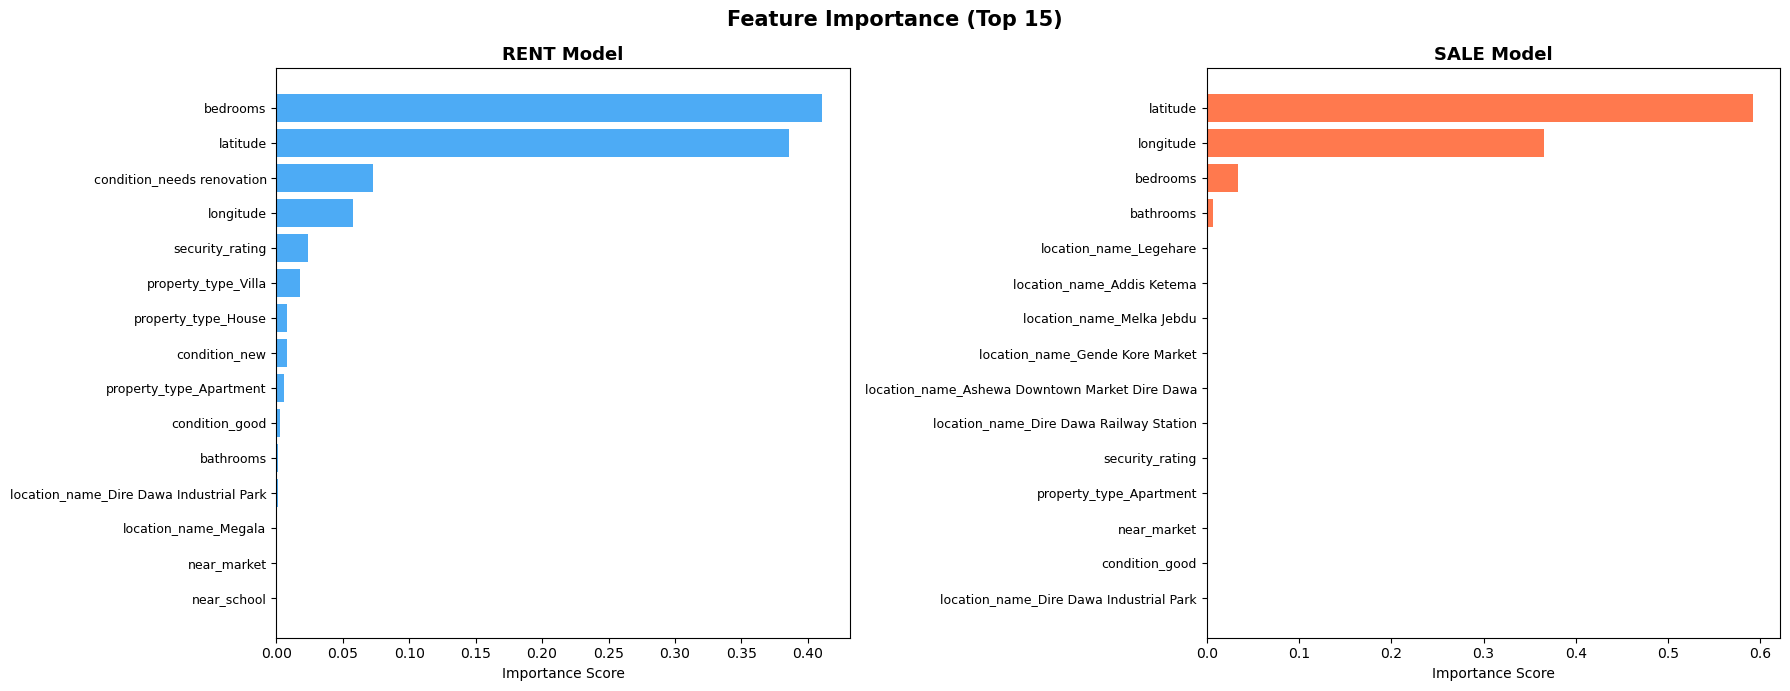

📊 Feature importance saved as feature_importance.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance (Top 15)', fontsize=15, fontweight='bold')

for ax, (label, model, X, y), color in zip(
    axes,
    [('RENT', rent_model, X_rent, y_rent), ('SALE', sale_model, X_sale, y_sale)],
    ['#2196F3', '#FF5722']
):
    model.fit(X, y)   # refit on full data
    regressor   = model.named_steps['regressor']
    preprocessor = model.named_steps['preprocessor']

    # Get feature names after one-hot encoding
    cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(
        ['location_name', 'property_type', 'condition']
    )
    num_features = np.array([
        'latitude', 'longitude', 'bedrooms', 'bathrooms',
        'near_school', 'near_hospital', 'near_market', 'parking', 'security_rating'
    ])
    all_features = np.concatenate([cat_features, num_features])

    importances = regressor.feature_importances_
    top_idx = np.argsort(importances)[-15:]  # top 15

    ax.barh(all_features[top_idx], importances[top_idx], color=color, alpha=0.8)
    ax.set_title(f'{label} Model', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance Score')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Feature importance saved as feature_importance.png')

## 5️⃣  Final Summary Table

In [6]:
print('\n' + '='*60)
print('  FINAL MODEL EVALUATION SUMMARY')
print('='*60)
print(f'{"Metric":<30} {"RENT Model":>14} {"SALE Model":>14}')
print('-'*60)

for label, model, X, y in [
    ('RENT', rent_model, X_rent, y_rent),
    ('SALE', sale_model, X_sale, y_sale)
]:
    cv_data = results[label]
    results[label]['cv_r2_mean']  = cv_data['cv_r2'].mean()
    results[label]['cv_mae_mean'] = cv_data['cv_mae'].mean()
    results[label]['cv_rmse_mean']= cv_data['cv_rmse'].mean()

rows = [
    ('Algorithm',         'RandomForest',                    'RandomForest'),
    ('Train R²',          f"{results['RENT']['train_r2']:.4f}",  f"{results['SALE']['train_r2']:.4f}"),
    ('CV R² (5-fold)',    f"{results['RENT']['cv_r2_mean']:.4f}", f"{results['SALE']['cv_r2_mean']:.4f}"),
    ('CV MAE (ETB/m²)',   f"{results['RENT']['cv_mae_mean']:.2f}",f"{results['SALE']['cv_mae_mean']:.2f}"),
    ('CV RMSE (ETB/m²)',  f"{results['RENT']['cv_rmse_mean']:.2f}",f"{results['SALE']['cv_rmse_mean']:.2f}"),
    ('Overfit Gap',
     f"{results['RENT']['train_r2'] - results['RENT']['cv_r2_mean']:.4f}",
     f"{results['SALE']['train_r2'] - results['SALE']['cv_r2_mean']:.4f}"),
]

for row in rows:
    print(f'{row[0]:<30} {row[1]:>14} {row[2]:>14}')

print('='*60)
print('  Overfit Gap < 0.05 = healthy   |   > 0.05 = overfitting')
print('='*60)


  FINAL MODEL EVALUATION SUMMARY
Metric                             RENT Model     SALE Model
------------------------------------------------------------
Algorithm                        RandomForest   RandomForest
Train R²                               0.9987         0.9999
CV R² (5-fold)                         0.9875         0.9993
CV MAE (ETB/m²)                         17.63         329.79
CV RMSE (ETB/m²)                        25.87         599.77
Overfit Gap                            0.0111         0.0006
  Overfit Gap < 0.05 = healthy   |   > 0.05 = overfitting
